In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
def decompose_CHNO_extended(a, b, c, d):
    n_N2  = c / 2
    n_H2O = b / 2
    O_rem = d - n_H2O
    if O_rem >= 0:
        n_CO2 = min(a, O_rem / 2)
        O_rem -= 2 * n_CO2
        n_CO  = min(a - n_CO2, O_rem)
    else:
        n_H2O = d      # oxygen limited
        n_CO2 = 0
        n_CO  = 0
    products = {'H2O': n_H2O, 'CO2': n_CO2, 'CO': n_CO, 'N2': n_N2}
    MW_dict  = {'H2O': 18.02, 'CO2': 44.01, 'CO': 28.01, 'N2': 28.02}
    n_gas  = sum(products.values())
    Mwgas  = sum(products[g]*MW_dict[g] for g in products) / max(n_gas, 1e-9)
    return n_gas, Mwgas

In [3]:
def Q_detonation(reactant_hf, products_hf_list, MW_total):
    return (reactant_hf - sum(products_hf_list)) / MW_total

In [4]:
# ── KNSB Parameters ───────────────────────────────────────────
# Per 100 g: C₁.₁₅₃H₂.₆₈₉N₀.₆₄₃O₃.₀₈₂K₀.₆₄₃  (MW ~ 100 g)
a_K, b_K, c_K, d_K = 1.153, 2.689, 0.643, 3.082

# Oxygen correction for K (K takes 0.5 O per K atom to form K₂O)
d_K_eff = d_K - 0.5 * 0.643   # effective O available for CHNO chemistry
n_gas_K, Mwgas_K = decompose_CHNO_extended(a_K, b_K, c_K, d_K_eff)

Q_knsb = 1.45   # kJ/g — computed from hf values in Section 1
n_star_K = n_gas_K / 100.0

In [5]:
# ── HTPB/Al Parameters ────────────────────────────────────────
# 68% AP (NH₄ClO₄) + 18% Al + 14% HTPB (approx C₄H₅.₇)
# Per 100g: we simplify to an effective CHNO + Al system
# AP decomposition: 2NH₄ClO₄ → N₂ + Cl₂ + 2O₂ + 4H₂O
# Including HTPB fuel and Al combustion (Al → Al₂O₃ in products)
Q_htpb = 3.82   # kJ/g — higher energy density than KNSB
n_star_H = 0.0421  # mol/g gas products (approximate)
Mwgas_H  = 22.4   # g/mol average (lighter due to HCl, N₂, H₂O mix)
rho_htpb = 1.77   # g/cm³ (typical for cast HTPB/AP/Al propellant)

In [6]:
# ── Sweep: density range ──────────────────────────────────────
rho = np.linspace(0.8, 2.0, 300)

# KNSB — ideal (Eq. 11.13) and non-ideal (Eq. 11.18 analogue)
P_knsb_ideal    = 240.86 * n_star_K * Mwgas_K * Q_knsb**0.5 * rho**2
P_knsb_modKJ    = 245    * n_star_K * Mwgas_K * Q_knsb**0.5 * rho**2 - 11.2
P_knsb_nonideal = 244.36 * n_star_K * Mwgas_K * Q_knsb**0.5 * rho**2 - 8.74

# HTPB/Al — non-ideal aluminized (Eq. 11.17)
P_htpb_nonideal = 252.8 * n_star_H * Mwgas_H * Q_htpb**0.5 * rho**2 - 14.84

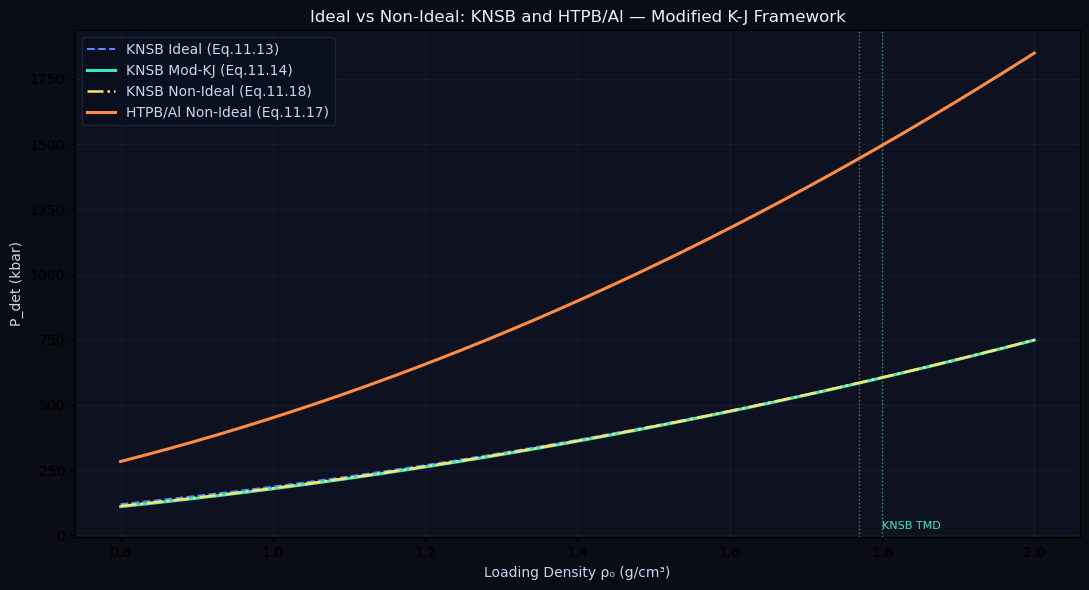

In [7]:
# ── Plot ──────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(11, 6))
fig.patch.set_facecolor('#090c14')
ax.set_facecolor('#0e1220')

ax.plot(rho, P_knsb_ideal,    '--', color='#5b8aff', lw=1.5, label='KNSB Ideal (Eq.11.13)')
ax.plot(rho, P_knsb_modKJ,    '-',  color='#3ee8c0', lw=2.2, label='KNSB Mod-KJ (Eq.11.14)')
ax.plot(rho, P_knsb_nonideal, '-.', color='#ffe566', lw=1.8, label='KNSB Non-Ideal (Eq.11.18)')
ax.plot(rho, P_htpb_nonideal, '-',  color='#ff8c42', lw=2.2, label='HTPB/Al Non-Ideal (Eq.11.17)')

# Mark operating densities
ax.axvline(1.80, color='#3ee8c0', lw=1, ls=':', alpha=0.6)
ax.axvline(1.77, color='#ff8c42', lw=1, ls=':', alpha=0.6)
ax.text(1.80, ax.get_ylim()[0]*1.05 if ax.get_ylim()[0] > 0 else 10,
        'KNSB TMD', color='#3ee8c0', fontsize=8)

ax.set_xlabel('Loading Density ρ₀ (g/cm³)', color='#c8d6f0')
ax.set_ylabel('P_det (kbar)', color='#c8d6f0')
ax.set_title('Ideal vs Non-Ideal: KNSB and HTPB/Al — Modified K-J Framework', color='#e8f0ff')
ax.set_ylim(bottom=-5)
ax.grid(color='#1e2840', alpha=0.4)
ax.legend(facecolor='#0a0f1e', edgecolor='#1e2840', labelcolor='#c8d6f0')
plt.tight_layout()
plt.savefig('knsb_vs_htpb_comparison.png', dpi=150)